# DAY 4 — COMPUTER VISION PRACTICALS

This notebook contains the computer vision practicals completed during the AI Bootcamp.

Topics covered:
- Basic image processing
- Image classification
- Face detection
- Object detection
- Video processing
- Draw Canvas
- Neural network based practical

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

## 1. Basic Image Processing

We will load an image and perform basic image processing operations using OpenCV.

In [4]:
img = cv2.imread("practical_img/images.jpeg")
print(type(img))

<class 'numpy.ndarray'>


In [5]:
print("Image shape:", img.shape)

Image shape: (552, 554, 3)


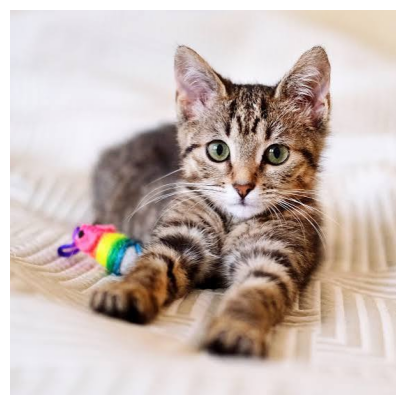

In [6]:
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### Resizing the Image

The image can be resized to a smaller or larger dimension using OpenCV.

In [7]:
resized_img = cv2.resize(img, (300, 300))

print("Resized image shape:", resized_img.shape)

Resized image shape: (300, 300, 3)


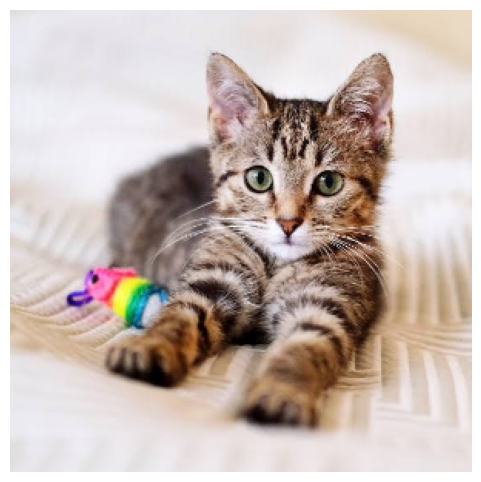

In [8]:
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### Flipping the Image

The image can be flipped horizontally or vertically using OpenCV.

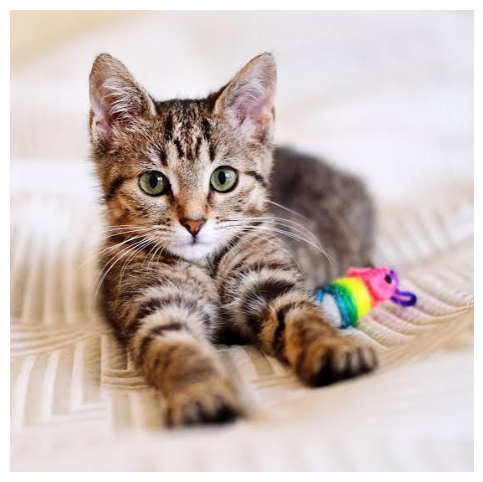

In [9]:
flipped_img = cv2.flip(img, 1)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(flipped_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### Cropping the Image

A specific part of an image can be selected using array slicing.

In [10]:
cropped_img = img[80:400, 100:450]

print("Cropped image shape:", cropped_img.shape)

Cropped image shape: (320, 350, 3)


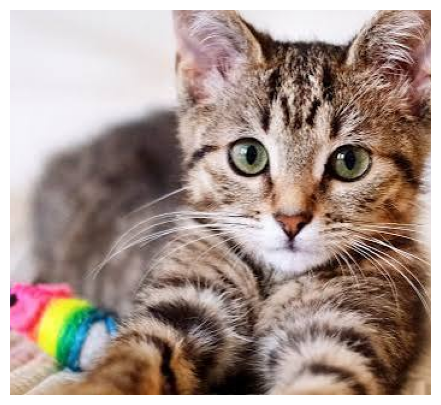

In [11]:
plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### Saving the Processed Image

The processed image can be saved to a file using OpenCV.

In [12]:
cv2.imwrite("practical_img/cat_cropped.jpeg", cropped_img)
print("Cropped image saved successfully.")

Cropped image saved successfully.


## 2. Image Classification Using CNN

A Convolutional Neural Network can learn visual patterns from images and classify them into different categories.

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

dataset_path = "practical_img"

print("Dataset folder:", dataset_path)

Dataset folder: practical_img


In [6]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax")
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,762 (120.16 KB)

 Trainable params: 30,762 (120.16 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train[:5000]
y_train = y_train[:5000]
x_test = x_test[:1000]
y_test = y_test[:1000]

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data: (5000, 28, 28, 1)
Testing data: (1000, 28, 28, 1)


In [7]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = cnn_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6373 - loss: 1.2016 - val_accuracy: 0.8720 - val_loss: 0.4419
Epoch 2/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9058 - loss: 0.3337 - val_accuracy: 0.9360 - val_loss: 0.2853
Epoch 3/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9376 - loss: 0.2222 - val_accuracy: 0.9260 - val_loss: 0.2473


In [8]:
test_loss, test_accuracy = cnn_model.evaluate(x_test, y_test, verbose=0)

print("Test accuracy:", round(test_accuracy * 100, 2), "%")

Test accuracy: 91.5 %


In [9]:
prediction = cnn_model.predict(x_test[:1], verbose=0)
predicted_label = np.argmax(prediction)

print("Predicted digit:", predicted_label)
print("Actual digit:", y_test[0])

Predicted digit: 7
Actual digit: 7


### Preparing the Image Dataset

For this classification task, images are organized into separate folders based on their categories. This allows the model to learn the visual differences between the classes.

In [1]:
dataset_path = "practical_img"
print("Dataset folder:", dataset_path)

Dataset folder: practical_img


## 3. Face Detection

Face detection identifies human faces in an image using computer vision techniques.

Here, we use OpenCV's Haar Cascade classifier to detect faces and draw bounding boxes around them.

In [19]:
import cv2

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

print("Face detector loaded:", not face_cascade.empty())

Face detector loaded: True


In [20]:
image = cv2.imread("practical_img/images.jpeg")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

cv2.imwrite("practical_img/face_detection_result.jpg", image)

print("Faces detected:", len(faces))
print("Face detection completed.")
print("Result saved as: practical_img/face_detection_result.jpg")

Faces detected: 0
Face detection completed.
Result saved as: practical_img/face_detection_result.jpg


## 4. Object Detection

Object detection identifies objects present in an image or video and marks their locations using bounding boxes.

For this practical, we will use a YOLO-based detector to identify objects in a live camera feed.

In [5]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLO model loaded successfully.")

YOLO model loaded successfully.


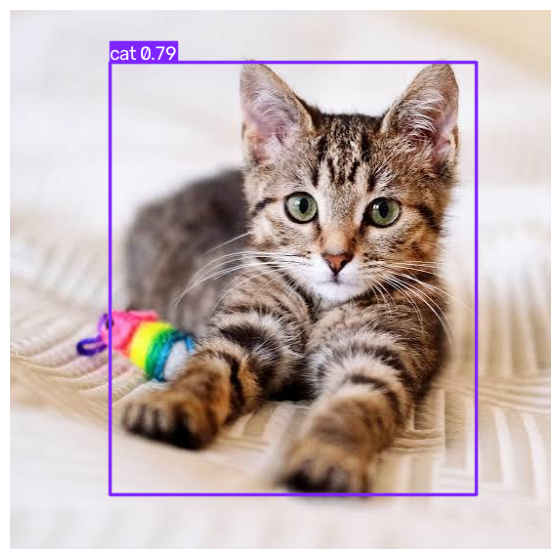

In [7]:
import matplotlib.pyplot as plt

detected_image = results[0].plot()

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(detected_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## 5. Draw Canvas

A virtual drawing canvas can be created using computer vision by tracking a colored object in the camera feed.

In this practical, the detected object acts like a virtual marker and its movement is used to draw on the canvas.

In [9]:
import cv2
import numpy as np

print("Draw Canvas setup ready.")

Draw Canvas setup ready.


In [10]:
cap = cv2.VideoCapture(0)

if cap.isOpened():
    print("Camera opened successfully.")
else:
    print("Could not open the camera.")
    
cap.release()

Camera opened successfully.


In [11]:
cap = cv2.VideoCapture(0)

canvas = np.zeros((480, 640, 3), dtype=np.uint8)
frame_count = 0

while frame_count < 30:
    success, frame = cap.read()

    if not success:
        break

    frame = cv2.flip(frame, 1)
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([100, 120, 50])
    upper_blue = np.array([140, 255, 255])
    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)

        if cv2.contourArea(largest) > 500:
            x, y, w, h = cv2.boundingRect(largest)
            cv2.circle(canvas, (x + w // 2, y + h // 2), 5, (255, 0, 0), -1)

    frame_count += 1

cap.release()

cv2.imwrite("practical_img/draw_canvas_result.jpg", canvas)

print("Draw Canvas frames processed:", frame_count)
print("Canvas result saved successfully.")

Draw Canvas frames processed: 30
Canvas result saved successfully.


### Detecting the Virtual Marker

A colored marker is detected by converting the camera frame from BGR to HSV color space. The selected color range is then used to create a mask.

In [11]:
lower_color = np.array([100, 120, 50])
upper_color = np.array([140, 255, 255])

print("Marker color range set.")

Marker color range set.


In [13]:
canvas = np.zeros((480, 640, 3), dtype=np.uint8)

cap = cv2.VideoCapture(0)

while cap.isOpened():
    success, frame = cap.read()

    if not success:
        break

    frame = cv2.flip(frame, 1)

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lower_color, upper_color)

    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)

        if cv2.contourArea(largest_contour) > 500:
            x, y, w, h = cv2.boundingRect(largest_contour)
            center = (x + w // 2, y + h // 2)

            cv2.circle(frame, center, 10, (255, 0, 0), -1)
            cv2.circle(canvas, center, 8, (255, 0, 0), -1)

    output = cv2.addWeighted(frame, 1, canvas, 1, 0)

    cv2.imshow("Draw Canvas", output)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

## 6. Video Processing

Video processing involves reading and working with video frames using OpenCV.

A video can be treated as a sequence of individual frames, which can then be displayed or processed one by one.

In [18]:
cap = cv2.VideoCapture(0)

print("Camera opened:", cap.isOpened())

success, frame = cap.read()

print("Frame captured:", success)

if success:
    print("Frame shape:", frame.shape)

cap.release()

Camera opened: True
Frame captured: False


In [13]:
cap = cv2.VideoCapture(0)

frame_count = 0

while frame_count < 30:
    success, frame = cap.read()

    if not success:
        break

    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frame_count += 1

cap.release()

print("Frames processed:", frame_count)

Frames processed: 30


## 7. Neural Network

A neural network learns patterns from input data by passing information through connected layers of artificial neurons.

In this practical, we will use a simple neural network model to understand the basic training process.

In [16]:
from tensorflow.keras import layers, models

nn_model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

nn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
nn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

nn_history = nn_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7111 - loss: 1.0758 - val_accuracy: 0.8600 - val_loss: 0.5364
Epoch 2/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step - accuracy: 0.8853 - loss: 0.4225 - val_accuracy: 0.8960 - val_loss: 0.3828
Epoch 3/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step - accuracy: 0.9171 - loss: 0.3242 - val_accuracy: 0.9060 - val_loss: 0.3373


In [18]:
nn_loss, nn_accuracy = nn_model.evaluate(x_test, y_test, verbose=0)

print("Neural Network test accuracy:", round(nn_accuracy * 100, 2), "%")

Neural Network test accuracy: 87.4 %


In [19]:
prediction = nn_model.predict(x_test[:1], verbose=0)

predicted_label = np.argmax(prediction)

print("Predicted digit:", predicted_label)
print("Actual digit:", y_test[0])

Predicted digit: 7
Actual digit: 7


## Conclusion

This practical covered basic computer vision operations, image detection, neural networks, and convolutional neural networks.

The experiments helped demonstrate how images can be processed and how neural network models can learn patterns from image data.